# 04 · Entrenamiento del predictor del día siguiente

**Requiere TensorFlow** (Google Colab, o un entorno local con
`requirements.txt` instalado — ver README, sección "Entorno").

Dos pasos, con separacion temporal estricta. Primero se selecciona la
arquitectura por el ERROR EN VALIDACIÓN (nunca en test); despues, con esa
arquitectura ya fijada, se comparan los generadores en el test final.

1. **Elegir arquitectura** (enunciado, paso 4): con SOLO la ventana real
   disponible para entrenar (sin ningún día sintético), se comparan
   constante / baseline / lineal / densa / CNN / CNN profunda / RNN / RNN
   profunda — misma comparación que `Taller_con_Datos_SP500_promedio.ipynb`,
   pero con nuestros bancos y 2 canales por banco (retorno + volatilidad
   realizada). La tabla generada `04_comparacion_arquitecturas.csv`
   incluye metricas de validacion (`split=validation`).

   **El modelo `constante`** (predecir siempre la media por banco del
   train, ignorando X) es la referencia decisiva. El otro suelo,
   `baseline`, repite el retorno del día anterior; como los retornos
   diarios son casi incorrelados en el tiempo, eso es *activamente* peor
   que no predecir nada, y comparar solo contra él hace que cualquier red
   parezca buena. Una red que no bate a `constante` no ha aprendido
   ninguna señal de la ventana X: solo el nivel medio.
2. **Rejilla años de sintéticos × generador**: con la arquitectura
   ganadora, se entrena una versión por cada combinación
   (`SYNTH_DEPTH_YEARS_GRID` años de backfill sintético añadidos) ×
   (generador que rellenó esos años), evaluando siempre en el MISMO test
   real (`REAL_TEST_HOLDOUT_START_DATE` en adelante). Ese test no se usa
   para decidir la arquitectura.

**Sobre las fechas** (ver `src/config.py`): la ventana real de
`REAL_INTRADAY_YEARS` (~5,5 años) se reparte en train/val/test — val y
test se comen el último año, así que lo que queda para entrenar "solo con
reales" son ~4,6 años (`synth_years=0`). A partir de ahí, `synth_years` cuenta
hacia atrás desde `REAL_INTRADAY_START_DATE` cuánta historia con
volatilidad SINTÉTICA se añade — el final del entrenamiento
(`VAL_START_DATE`) es siempre el mismo, no cambia con la profundidad.

**Sobre la métrica — MAE como *loss*, no solo como número final**: la
diapositiva de teoría del taller ("REAL PROBLEM",
`2026_Taller_Generativos.pdf` pág. 11-12) especifica **"Learning:
minimize MAE"** para el problema real que motiva el taller, y reporta el
error en las unidades del target (Kelvin) — la ventaja de MAE frente a
MSE, que queda en unidades al cuadrado. El retorno diario es igual de
heavy-tailed que ese problema (ver notebook 02: la Gaussiana no
reproduce el pico leptocúrtico de los datos reales), así que entrenar
con MSE dejaría que los pocos días de retorno extremo dominen el
gradiente. Por eso aquí se entrena con `loss='mae'` (parámetro de
`build_predictor_*`, ver `LOSS_FUNCTION` más abajo). Se reportan MAE,
MSE y precisión direccional para cada modelo.

**Sobre la convergencia**: `EarlyStopping` con `patience` alto (no unas
pocas epochs) — el criterio de parada exige que `val_loss` lleve
`EARLY_STOPPING_PATIENCE` epochs SEGUIDAS sin mejorar, así que cuando un
entrenamiento para, la curva de loss ya lleva un tramo largo y plano:
es la evidencia visual de convergencia que pide el enunciado, no solo
"dejó de mejorar hace poco".

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, modelos, plotting as pl, train_utils as tu

# EPOCHS_* son un techo de seguridad, no el nº de epochs que se entrena
# realmente: tanto run_architecture_comparison como run_depth_grid paran
# antes vía EarlyStopping (ver arriba). El techo se deja holgado para que
# sea EarlyStopping, no el techo, quien decida cuándo parar.
EPOCHS_ARQUITECTURA = 300
EPOCHS_REJILLA = 500
BATCH_SIZE = 256
EARLY_STOPPING_PATIENCE = 20
LOSS_FUNCTION = "mae"

# Regularizacion, aplicada POR IGUAL a la comparacion de arquitecturas y a
# la rejilla: seleccionar la arquitectura con un regimen y entrenarla luego
# con otro no compararia lo mismo.
#
# Sin esto, las redes memorizan: con 1.145 ventanas de entrenamiento y hasta
# 394.009 parametros (la densa: 344 parametros por muestra), el train baja a
# 0.006 mientras la validacion sube a 0.0136 — el modelo ajusta el
# entrenamiento el doble de bien que la validacion. Con dropout=0.3 y
# L2=1e-4 la curva de validacion se queda PLANA tras el minimo (sube +0.1%
# en vez de +17.6%), que es lo que de verdad significa "ha convergido".
#
# NOTA sobre las curvas: con dropout activo la loss de TRAIN sale por ENCIMA
# de la de validacion. Es lo esperado, no un error: durante el entrenamiento
# se apaga el 30% de las neuronas, mientras que en validacion el modelo va
# completo.
DROPOUT = 0.3
L2_REG = 1e-4

# PURGA / EMBARGO. Cada muestra usa una ventana de WINDOW_X_DAYS dias, asi
# que una fila de entrenamiento fechada pocos dias antes de VAL_START_DATE
# comparte casi toda su ventana de entrada con las primeras filas de
# validacion. No es look-ahead (ninguna muestra usa nada posterior a su
# propia fecha), pero crea dependencia estadistica entre train y validacion
# y hace que la metrica de validacion salga OPTIMISTA — y esa metrica es la
# que elige la arquitectura.
#
# `train_utils.split_fold` ya aplicaba esta purga en la validacion
# walk-forward, citando la practica estandar en series financieras
# (purging/embargo, Lopez de Prado), pero el pipeline que produce los
# resultados no la usaba. Se aplica igual que alli: retrasando el final del
# entrenamiento, no tocando las funciones de recorte.
#
# Coste: ~41 de 1.145 filas (3,6 %) en el tramo mas pequeno. El TEST ya
# estaba limpio (183 dias naturales lo separan del fin del entrenamiento,
# mas que los 60 de la ventana), asi que esto solo corrige la validacion.
EMBARGO_DAYS = config.WINDOW_X_DAYS
TRAIN_END = str(
    (pd.Timestamp(config.VAL_START_DATE) - pd.Timedelta(days=EMBARGO_DAYS)).date()
)
print(f"entrenamiento hasta {TRAIN_END} (VAL empieza {config.VAL_START_DATE}, "
      f"embargo de {EMBARGO_DAYS} dias)")

entrenamiento hasta 2025-04-02 (VAL empieza 2025-06-01, embargo de 60 dias)


## 1. Cargar los 4 datasets de 30 años (notebook 03)

In [2]:
datasets_by_generator = {}
for name in ["noise", "gaussian", "rbig", "gan"]:
    path = config.INTERIM_DIR / f"dataset_{name}.npz"
    if not path.exists():
        continue
    npz = np.load(path, allow_pickle=True)
    idx = pd.DatetimeIndex(npz["idx"])
    datasets_by_generator[name] = (npz["X"], npz["Y"], idx, npz["is_synthetic"])
    print(f"{name}: X {npz['X'].shape}  Y {npz['Y'].shape}")

N_CHANNELS = datasets_by_generator[next(iter(datasets_by_generator))][0].shape[-1]  # 2 * N_PREDICTOR_TICKERS
assert N_CHANNELS == 2 * config.N_PREDICTOR_TICKERS

noise: X (7322, 60, 50)  Y (7322, 25)
gaussian: X (7322, 60, 50)  Y (7322, 25)


rbig: X (7322, 60, 50)  Y (7322, 25)


gan: X (7322, 60, 50)  Y (7322, 25)


## 2. Separar validación y test (reales, jamás usados por los generadores)

In [3]:
def val_test_split(X, Y, idx):
    val_mask = (idx >= pd.Timestamp(config.VAL_START_DATE)) & (idx < pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE))
    test_mask = idx >= pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE)
    return (X[val_mask], Y[val_mask]), (X[test_mask], Y[test_mask])

ref_name = next(iter(datasets_by_generator))
(X_val, Y_val), (X_test, Y_test) = val_test_split(*datasets_by_generator[ref_name][:3])
print(f"val: {X_val.shape}   test: {X_test.shape}")

val: (126, 60, 50)   test: (122, 60, 50)


## 3. Elegir arquitectura, usando SOLO la ventana real disponible

`synth_years=0`: ni un solo día con volatilidad sintética todavía (ver
`train_utils.slice_by_depth`) — solo los ~4,6 años reales que quedan entre
`REAL_INTRADAY_START_DATE` (2020-11) y `VAL_START_DATE` (2025-06).

In [4]:
X_full, Y_full, idx_full, is_synth_full = datasets_by_generator[ref_name]
X_train_arch, Y_train_arch, _, _ = tu.slice_by_depth(
    X_full, Y_full, idx_full, synth_years=0,
    train_end=TRAIN_END, synth_anchor=config.REAL_INTRADAY_START_DATE,
    is_synthetic=is_synth_full,
)
print("train (arquitectura, solo reales):", X_train_arch.shape)

output_dim = config.N_PREDICTOR_TICKERS
window_x = config.WINDOW_X_DAYS

REG = dict(dropout=DROPOUT, l2=L2_REG, loss=LOSS_FUNCTION)

architectures = {
    # Los tres primeros no tienen parametros que aprender de la ventana X:
    # son el suelo contra el que hay que medir a las redes.
    "constante": lambda: modelos.build_predictor_constant(),
    "baseline": lambda: modelos.build_predictor_baseline(output_dim=output_dim),
    "linear": lambda: modelos.build_predictor_linear(),
    "dense": lambda: modelos.build_predictor_dense(
        window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), **REG
    ),
    "cnn_1bloque": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64,), **REG
    ),
    "cnn_3bloques": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), **REG
    ),
    "rnn_1capa": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64,), **REG
    ),
    "rnn_2capas": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), **REG
    ),
}

# Checkpoint, por el mismo motivo que en las rejillas: `scripts/
# rejilla_paralela.py` LEE de esta tabla que arquitectura entrenar, asi que
# si el notebook la recalculase despues de la rejilla podria elegir otra red
# y quedar incoherente con lo ya entrenado. Con checkpoint, la comparacion
# se hace UNA vez y todo lo demas se cuelga de ella.
# Para rehacerla desde cero: borrar los dos ficheros.
_ARCH_CSV = config.TABLES_DIR / "04_comparacion_arquitecturas.csv"
_ARCH_HIST = config.INTERIM_DIR / "04_checkpoint_arquitecturas_histories.json"

if _ARCH_CSV.exists() and _ARCH_HIST.exists():
    import json
    arch_results = pd.read_csv(_ARCH_CSV, index_col=0)
    arch_histories = json.loads(_ARCH_HIST.read_text(encoding="utf-8"))
    print(f"comparacion de arquitecturas: reutilizando checkpoint "
          f"({len(arch_results)} modelos)")
else:
    arch_results, arch_histories = tu.run_architecture_comparison(
        architectures, X_train_arch, Y_train_arch, X_val, Y_val,
        epochs=EPOCHS_ARQUITECTURA, batch_size=BATCH_SIZE, verbose=0,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
    )
    arch_results.to_csv(_ARCH_CSV)
    import json
    _ARCH_HIST.write_text(json.dumps(
        {k: {m: [float(x) for x in v] for m, v in h.items()}
         for k, h in arch_histories.items()}, indent=2), encoding="utf-8")

arch_results.sort_values("mae")

train (arquitectura, solo reales): (1104, 60, 50)
comparacion de arquitecturas: reutilizando checkpoint (8 modelos)


,split,fit_seconds,mse,mae,directional_accuracy
model,,,,,
constante,validation,0.000334,0.000250,0.011509,0.527619
cnn_3bloques,validation,34.354820,0.000251,0.011519,0.526667
rnn_1capa,validation,25.368694,0.000251,0.011520,0.524127
rnn_2capas,validation,83.194051,0.000251,0.011521,0.520635
cnn_1bloque,validation,7.862596,0.000258,0.011691,0.510794
dense,validation,3.836705,0.000291,0.012450,0.495556
baseline,validation,0.000029,0.000514,0.017142,0.463492
linear,validation,0.142819,0.000705,0.020197,0.505397


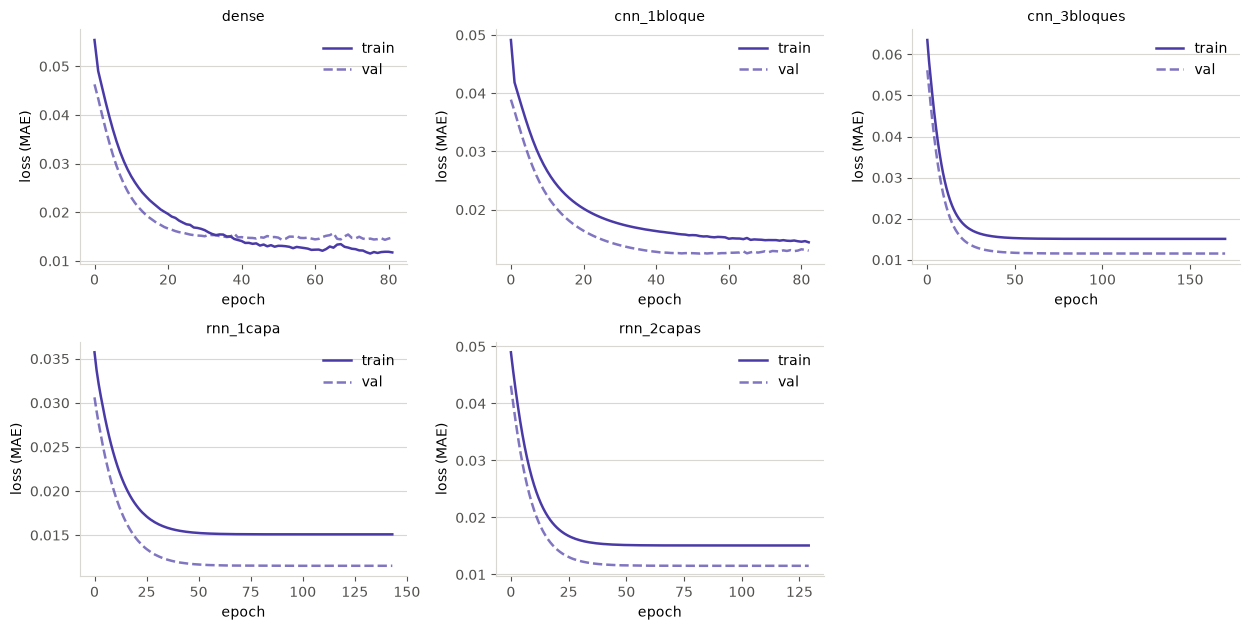

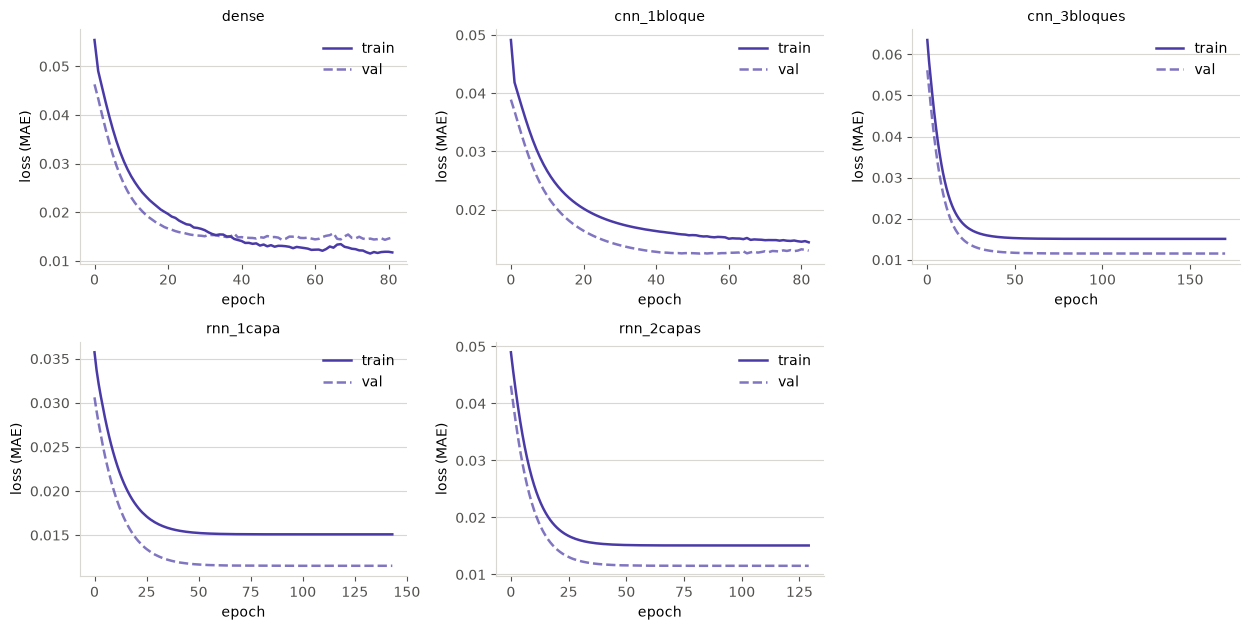

In [5]:
fig = pl.plot_loss_grid(arch_histories, ncols=3)
pl.savefig(fig, "04_loss_curvas_arquitecturas")
fig

Se elige la arquitectura con menor MAE en **validación**. Las columnas
`mae`, `mse` y `directional_accuracy` de `arch_results` son de validacion
(`split=validation`); el test se reserva para la comparacion de generadores
del siguiente paso.

Se distinguen dos cosas que antes se confundían en una sola variable:
`ARQUITECTURA_GANADORA` (quién gana, incluidas las referencias que no
aprenden) y `ARQUITECTURA_RED` (la mejor red, que es la que puede entrenar
la rejilla). Si el `constante` gana, la rejilla sigue adelante con la mejor
red —hace falta para comparar generadores— pero el aviso queda impreso.

In [6]:
REFERENCIAS_SIN_APRENDIZAJE = ["constante", "baseline", "linear"]

# `ARQUITECTURA_GANADORA` es quien gana de verdad, incluidas las referencias
# que no aprenden nada; `ARQUITECTURA_RED` es la mejor RED, que es la que
# puede entrenar la rejilla. Normalmente coinciden. Si no coinciden, ese
# desacuerdo ES el resultado y hay que decirlo, no taparlo.
ARQUITECTURA_GANADORA = arch_results["mae"].idxmin()

# REGLA DE UN ERROR ESTANDAR, la misma que scripts/analizar_hpsearch.py usa
# para elegir hiperparametros de los generadores: entre las candidatas que
# empatan dentro de un error estandar de la mejor, quedarse con la MAS
# SIMPLE (aqui: menos parametros).
#
# POR QUE: quedarse con el minimo a secas es quedarse con ruido. Las tres
# mejores redes estan separadas por 0.000003 en MAE de validacion — el 0.4%
# de un error estandar — y el orden entre ellas cambia de una ejecucion a
# otra. En una ejecucion gano rnn_1capa (38.465 parametros) y en la
# siguiente rnn_2capas (143.681, 4x mas lenta por epoca), sin que nada
# relevante cambiara. Elegir la mas simple entre las empatadas hace la
# decision estable Y barata, y es la practica estandar (Hastie et al.,
# "one-standard-error rule").
_redes = arch_results.drop(index=REFERENCIAS_SIN_APRENDIZAJE, errors="ignore")
_params = pd.Series(
    {n: architectures[n]().count_params() for n in _redes.index}, name="params"
)
_se = _redes["mae"].std() / max(len(_redes) ** 0.5, 1)
_umbral = _redes["mae"].min() + _se
_empatadas = _redes[_redes["mae"] <= _umbral]
ARQUITECTURA_RED = _params.loc[_empatadas.index].idxmin()

print(f"\nRegla de 1 e.e.: umbral MAE <= {_umbral:.6f} (mejor {_redes['mae'].min():.6f} "
      f"+ e.e. {_se:.6f})")
print(f"  empatadas: {list(_empatadas.index)}")
print(f"  elegida por simplicidad: {ARQUITECTURA_RED} "
      f"({_params[ARQUITECTURA_RED]:,} parametros)")
if _redes["mae"].idxmin() != ARQUITECTURA_RED:
    print(f"  (el minimo a secas habria sido {_redes['mae'].idxmin()}, "
          f"{_params[_redes['mae'].idxmin()]:,} parametros, por "
          f"{_redes['mae'].min() - _redes.loc[ARQUITECTURA_RED, 'mae']:+.6f} de MAE)")
mae_constante = arch_results.loc["constante", "mae"] if "constante" in arch_results.index else None
mejor_direccional = arch_results["directional_accuracy"].idxmax()
print("Arquitectura elegida (menor MAE):", ARQUITECTURA_GANADORA)

if mae_constante is not None:
    peores = arch_results[arch_results["mae"] >= mae_constante].index.difference(
        REFERENCIAS_SIN_APRENDIZAJE
    )
    print(f"\nMAE del predictor CONSTANTE (no mira X): {mae_constante:.6f}")
    print(f"Redes que NO lo superan: {list(peores) if len(peores) else 'ninguna'}")
    if ARQUITECTURA_GANADORA == "constante":
        print(
            "\n[RESULTADO] Ninguna red bate a predecir la media. La rejilla se\n"
            f"entrena igualmente con la mejor red ({ARQUITECTURA_RED}) para poder\n"
            "comparar generadores, pero la lectura honesta es que el predictor no\n"
            "extrae senal de la ventana X."
        )
    else:
        margen = mae_constante - arch_results.loc[ARQUITECTURA_RED, "mae"]
        print(f"Margen de la mejor red sobre la constante: {margen:+.6f} "
              f"({margen / mae_constante * 100:+.2f}%)")
if mejor_direccional != ARQUITECTURA_GANADORA:
    print(
        f"[AVISO] '{mejor_direccional}' tiene mejor precisión direccional "
        f"({arch_results.loc[mejor_direccional, 'directional_accuracy']:.3f} vs "
        f"{arch_results.loc[ARQUITECTURA_GANADORA, 'directional_accuracy']:.3f}) aunque peor MAE — "
        "vale la pena citar ambas arquitecturas en la presentación."
    )


def build_final_model():
    """Construye la mejor RED con la MISMA regularizacion (`REG`) con la que
    se la selecciono. Si se construyera sin dropout/L2 aqui, la rejilla
    entrenaria un modelo distinto del que gano la comparacion."""
    if ARQUITECTURA_RED == "cnn_1bloque":
        return modelos.build_predictor_cnn(window_x, N_CHANNELS, output_dim, conv_filters=(64,), **REG)
    if ARQUITECTURA_RED == "cnn_3bloques":
        return modelos.build_predictor_cnn(
            window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), **REG
        )
    if ARQUITECTURA_RED == "rnn_1capa":
        return modelos.build_predictor_rnn(window_x, N_CHANNELS, output_dim, lstm_units=(64,), **REG)
    if ARQUITECTURA_RED == "rnn_2capas":
        return modelos.build_predictor_rnn(
            window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), **REG
        )
    if ARQUITECTURA_RED == "dense":
        return modelos.build_predictor_dense(
            window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), **REG
        )
    raise ValueError(f"Arquitectura no keras seleccionada ({ARQUITECTURA_RED}); revisar manualmente.")


Regla de 1 e.e.: umbral MAE <= 0.011700 (mejor 0.011519 + e.e. 0.000180)
  empatadas: ['cnn_1bloque', 'cnn_3bloques', 'rnn_1capa', 'rnn_2capas']
  elegida por simplicidad: rnn_1capa (38,465 parametros)
  (el minimo a secas habria sido cnn_3bloques, 150,273 parametros, por -0.000000 de MAE)
Arquitectura elegida (menor MAE): constante

MAE del predictor CONSTANTE (no mira X): 0.011509
Redes que NO lo superan: ['cnn_1bloque', 'cnn_3bloques', 'dense', 'rnn_1capa', 'rnn_2capas']

[RESULTADO] Ninguna red bate a predecir la media. La rejilla se
entrena igualmente con la mejor red (rnn_1capa) para poder
comparar generadores, pero la lectura honesta es que el predictor no
extrae senal de la ventana X.


/private/tmp/claude-501/-Users-emiliosanchez-TallerB5-T1/5719b493-09bf-4874-bc08-16a36a93b8f9/scratchpad/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/private/tmp/claude-501/-Users-emiliosanchez-TallerB5-T1/5719b493-09bf-4874-bc08-16a36a93b8f9/scratchpad/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/private/tmp/claude-501/-Users-emiliosanchez-TallerB5-T1/5719b493-09bf-4874-bc08-16a36a93b8f9/scratchpad/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rn

## 4. Rejilla años de backfill sintético × generador

`synth_years=0` es idéntico para los 4 (sin sintéticos: fila
`solo_reales`, una sola vez); a partir de ahí cada generador aporta su
propio backfill y diverge. Se calcula también el desglose MAE/MSE/
precisión direccional POR BANCO (`ticker_names`), igual que la
comparación final de `Taller_con_Datos_SP500_promedio.ipynb`: una MAE
pooleada sobre los 25 bancos queda dominada por los de mayor volatilidad
(ver notebook 01, GBCI ~1.6x más volátil que JPM).

La función guarda checkpoints en `datos/interim` tras cada combinación. Si
el notebook se interrumpe, al reejecutarlo salta las combinaciones ya
terminadas y continua desde la primera pendiente.

In [7]:
results, histories, per_ticker = tu.run_depth_grid(
    build_final_model, datasets_by_generator, X_val, Y_val, X_test, Y_test,
    synth_years_grid=config.SYNTH_DEPTH_YEARS_GRID, train_end=TRAIN_END,
    synth_anchor=config.REAL_INTRADAY_START_DATE,
    epochs=EPOCHS_REJILLA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    ticker_names=config.PREDICTOR_TICKERS,
    checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad.csv",
    history_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad_histories.json",
    per_ticker_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad_por_banco.csv",
)
results.to_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
results.sort_values(["generator", "synth_years"])

[depth] saltando solo_reales, synth_years=0: ya existe checkpoint
[depth] saltando noise, synth_years=6: ya existe checkpoint
[depth] saltando gaussian, synth_years=6: ya existe checkpoint
[depth] saltando rbig, synth_years=6: ya existe checkpoint
[depth] saltando gan, synth_years=6: ya existe checkpoint
[depth] saltando noise, synth_years=12: ya existe checkpoint
[depth] saltando gaussian, synth_years=12: ya existe checkpoint
[depth] saltando rbig, synth_years=12: ya existe checkpoint
[depth] saltando gan, synth_years=12: ya existe checkpoint
[depth] saltando noise, synth_years=18: ya existe checkpoint
[depth] saltando gaussian, synth_years=18: ya existe checkpoint
[depth] saltando rbig, synth_years=18: ya existe checkpoint
[depth] saltando gan, synth_years=18: ya existe checkpoint
[depth] saltando noise, synth_years=24: ya existe checkpoint
[depth] saltando gaussian, synth_years=24: ya existe checkpoint
[depth] saltando rbig, synth_years=24: ya existe checkpoint
[depth] saltando gan,

,generator,synth_years,n_train,pct_synth,mse,mae,directional_accuracy
1,gan,6.0,2614,0.577659,0.000249,0.011756,0.526230
5,gan,12.0,4124,0.732299,0.000249,0.011755,0.524918
9,gan,18.0,5634,0.804047,0.000250,0.011769,0.519672
13,gan,24.0,7033,0.843026,0.000250,0.011780,0.500000
2,gaussian,6.0,2614,0.577659,0.000249,0.011758,0.526230
6,gaussian,12.0,4124,0.732299,0.000249,0.011755,0.524918
10,gaussian,18.0,5634,0.804047,0.000250,0.011769,0.519672
14,gaussian,24.0,7033,0.843026,0.000250,0.011776,0.503934
3,noise,6.0,2614,0.577659,0.000249,0.011756,0.526230
7,noise,12.0,4124,0.732299,0.000249,0.011754,0.524918


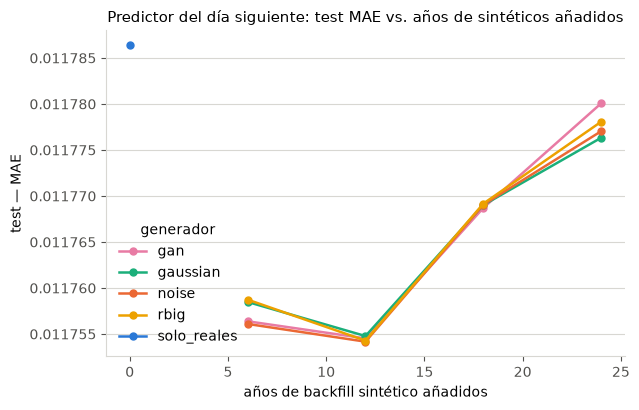

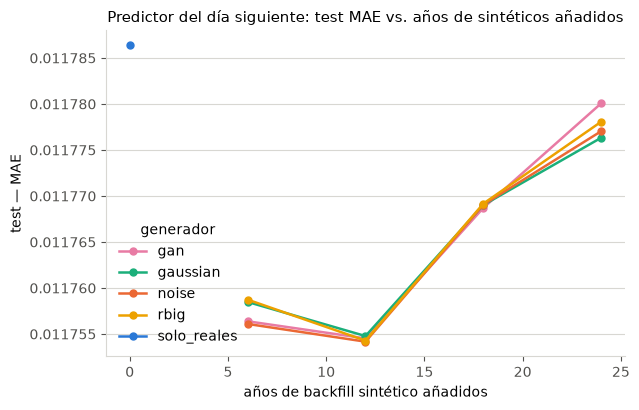

In [8]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "04_mae_vs_profundidad")
fig

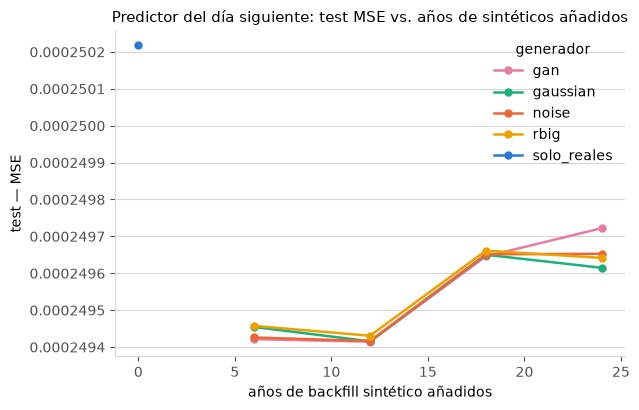

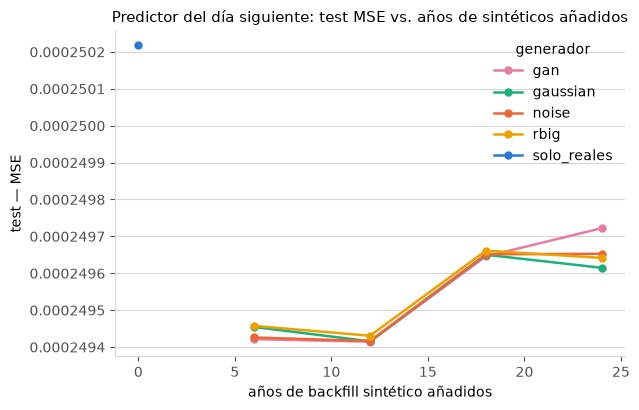

In [9]:
fig = pl.plot_depth_grid_results(results, metric="mse")
pl.savefig(fig, "04_mse_vs_profundidad")
fig

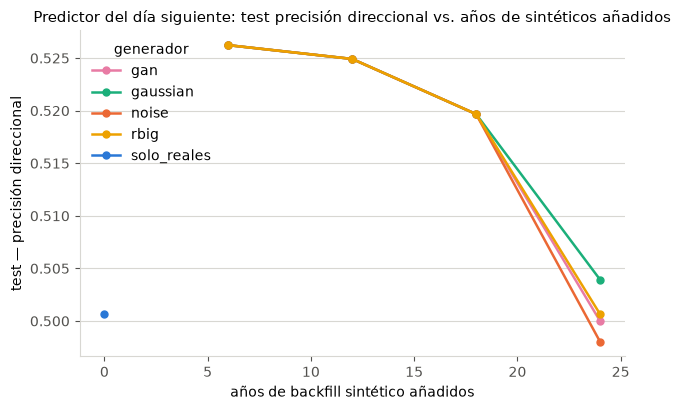

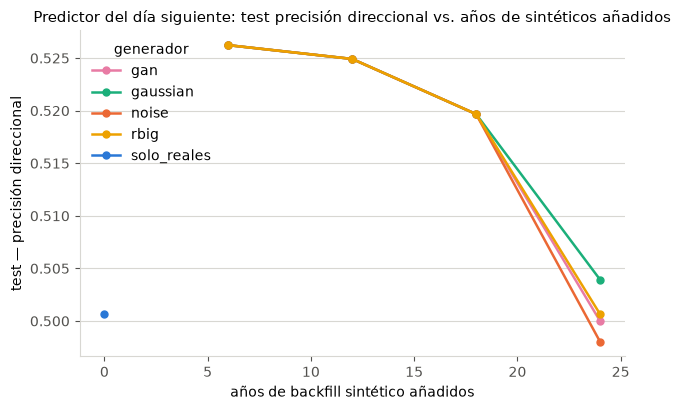

In [10]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "04_precision_direccional_vs_profundidad")
fig

## 5. Rejilla por PORCENTAJE de datos sintéticos × generador

El paso 3 del enunciado pide "datasets que tengan distinto **porcentaje**
de datos sintéticos y reales", y el paso 5 pide ver "cómo meter más o
menos datos sintéticos modifica el comportamiento del modelo". La rejilla
de la sección anterior está expresada en **años** de historia recuperada
—que es la rejilla natural del problema financiero— pero traducida a
porcentaje cae en 0% y luego ~57/72/80/84%: todo el tramo 0-57% queda sin
muestrear. Ahí no se puede ver la forma de la curva.

Esta rejilla barre el eje de forma uniforme (`PCT_SYNTH_GRID`),
manteniendo **todas** las filas reales disponibles y añadiendo las
sintéticas más recientes que hagan falta para alcanzar cada proporción
(`train_utils.slice_by_pct`). El caso `pct=1.0` entrena **sin ninguna
fila real**: mide cuánta señal real hace falta como ancla.

Misma arquitectura ganadora, mismos pesos reinicializados, mismo test
real — lo único que cambia entre versiones es la composición del
entrenamiento. Aquí no se calcula desglose por banco porque no se usa en
las salidas de porcentaje; así evitamos predicciones y checkpoints
auxiliares innecesarios.

In [11]:
results_pct, histories_pct, per_ticker_pct = tu.run_pct_grid(
    build_final_model, datasets_by_generator, X_val, Y_val, X_test, Y_test,
    pct_grid=config.PCT_SYNTH_GRID, train_end=TRAIN_END,
    epochs=EPOCHS_REJILLA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_porcentaje.csv",
    history_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_porcentaje_histories.json",
)
results_pct.to_csv(config.TABLES_DIR / "04_resultados_rejilla_porcentaje.csv")
results_pct.sort_values(["generator", "pct_objetivo"])

[pct] saltando solo_reales, pct=0.0: ya existe checkpoint
[pct] saltando noise, pct=0.25: ya existe checkpoint
[pct] saltando gaussian, pct=0.25: ya existe checkpoint
[pct] saltando rbig, pct=0.25: ya existe checkpoint
[pct] saltando gan, pct=0.25: ya existe checkpoint
[pct] saltando noise, pct=0.5: ya existe checkpoint
[pct] saltando gaussian, pct=0.5: ya existe checkpoint
[pct] saltando rbig, pct=0.5: ya existe checkpoint
[pct] saltando gan, pct=0.5: ya existe checkpoint
[pct] saltando noise, pct=0.75: ya existe checkpoint
[pct] saltando gaussian, pct=0.75: ya existe checkpoint
[pct] saltando rbig, pct=0.75: ya existe checkpoint
[pct] saltando gan, pct=0.75: ya existe checkpoint
[pct] saltando noise, pct=0.9: ya existe checkpoint
[pct] saltando gaussian, pct=0.9: ya existe checkpoint
[pct] saltando rbig, pct=0.9: ya existe checkpoint
[pct] saltando gan, pct=0.9: ya existe checkpoint
[pct] saltando noise, pct=1.0: ya existe checkpoint
[pct] saltando gaussian, pct=1.0: ya existe checkp

,generator,pct_objetivo,n_train,pct_synth,mse,mae,directional_accuracy
1,gan,0.25,1472,0.250000,0.00025,0.011775,0.512787
5,gan,0.50,2208,0.500000,0.00025,0.011763,0.523607
9,gan,0.75,4416,0.750000,0.00025,0.011771,0.519016
13,gan,0.90,7033,0.843026,0.00025,0.011780,0.500000
17,gan,1.00,5929,1.000000,0.00025,0.011759,0.516721
2,gaussian,0.25,1472,0.250000,0.00025,0.011776,0.508525
6,gaussian,0.50,2208,0.500000,0.00025,0.011762,0.523607
10,gaussian,0.75,4416,0.750000,0.00025,0.011771,0.512459
14,gaussian,0.90,7033,0.843026,0.00025,0.011776,0.503934
18,gaussian,1.00,5929,1.000000,0.00025,0.011756,0.524918


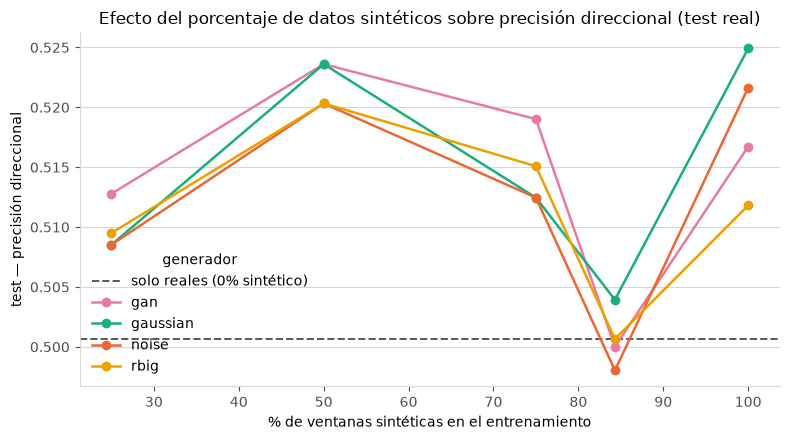

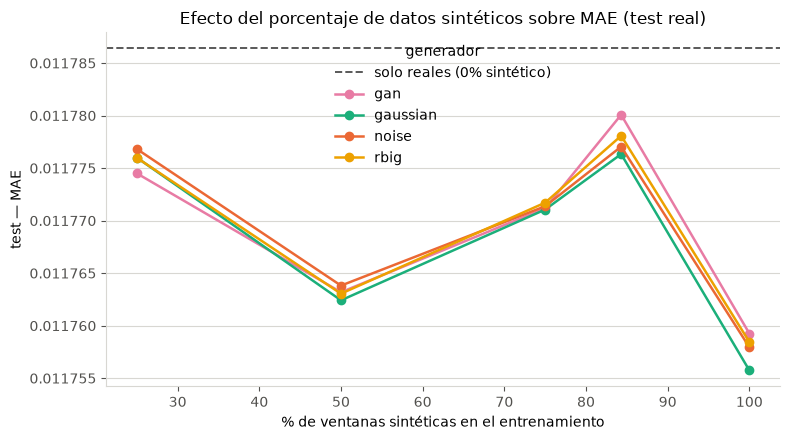

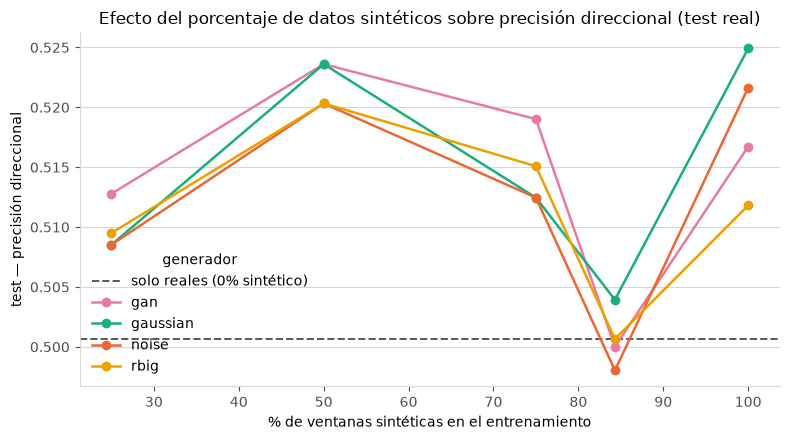

In [12]:
for metrica, nombre_fig in [
    ("mae", "04_mae_vs_porcentaje"),
    ("directional_accuracy", "04_precision_direccional_vs_porcentaje"),
]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    solo_reales = results_pct[results_pct.generator == "solo_reales"]
    if not solo_reales.empty:
        ax.axhline(
            solo_reales[metrica].iloc[0], color="0.35", linestyle="--", linewidth=1.4,
            label="solo reales (0% sintético)",
        )
    for gen_name, sub in results_pct[results_pct.generator != "solo_reales"].groupby("generator"):
        sub = sub.sort_values("pct_synth")
        ax.plot(sub.pct_synth * 100, sub[metrica], marker="o", linewidth=1.8,
                color=pl.color_for(gen_name), label=gen_name)
    ax.set_xlabel("% de ventanas sintéticas en el entrenamiento")
    ax.set_ylabel(f"test — {pl.metric_label(metrica)}")
    ax.set_title(
        f"Efecto del porcentaje de datos sintéticos sobre "
        f"{pl.metric_label(metrica)} (test real)"
    )
    ax.legend(frameon=False, title="generador")
    pl.style_axes(ax)
    fig.tight_layout()
    pl.savefig(fig, nombre_fig)

fig

## 6. Desglose por banco a máxima profundidad sintética

Gráfico de barras agrupado MAE por banco y generador (misma idea que el
bloque final de `Taller_con_Datos_SP500_promedio.ipynb`), en el punto de
mayor profundidad de la rejilla.

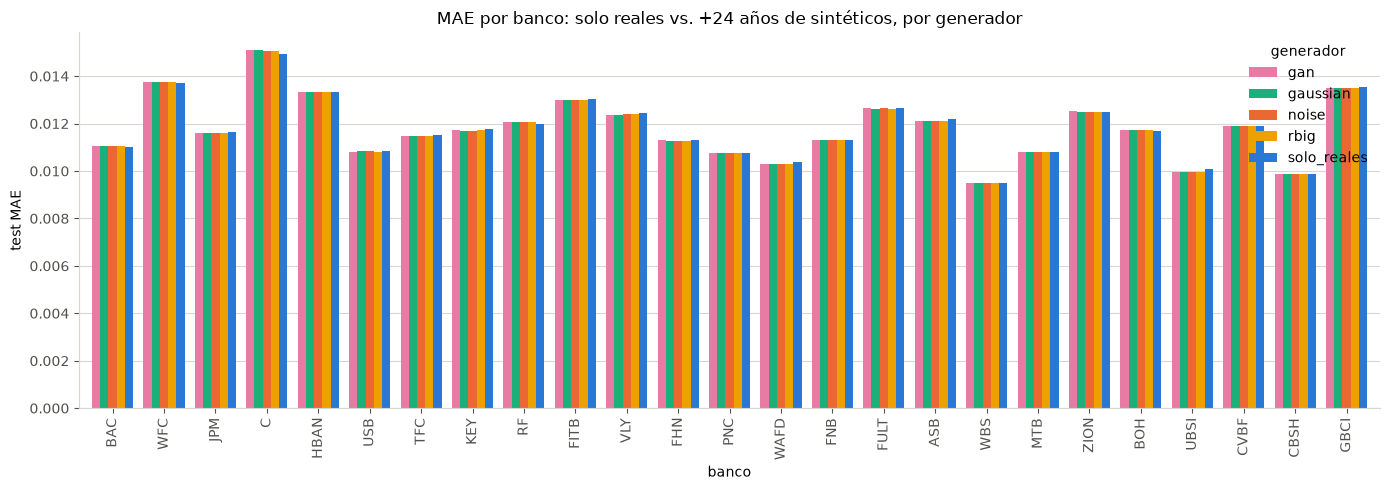

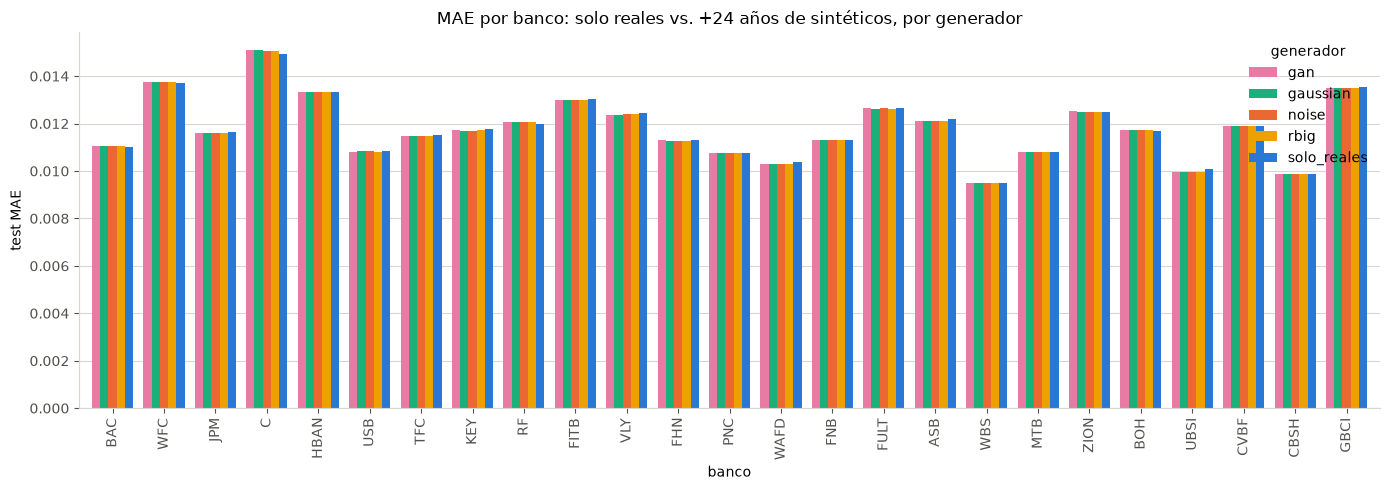

In [13]:
synth_years_max = config.SYNTH_DEPTH_YEARS_GRID[-1]
per_ticker_final = {
    gen_name: df for (gen_name, sy), df in per_ticker.items() if sy == synth_years_max
}
per_ticker_final["solo_reales"] = per_ticker[("solo_reales", config.SYNTH_DEPTH_YEARS_GRID[0])]

per_ticker_table = pd.concat(
    {name: df["mae"] for name, df in per_ticker_final.items()}, axis=1
)
per_ticker_table.to_csv(config.TABLES_DIR / "04_mae_por_banco.csv")

fig, ax = plt.subplots(figsize=(14, 5))
per_ticker_table.plot(
    kind="bar", ax=ax,
    color=[pl.color_for(c) for c in per_ticker_table.columns],
    width=0.8,
)
ax.set_ylabel("test MAE")
ax.set_xlabel("banco")
ax.set_title(f"MAE por banco: solo reales vs. +{synth_years_max} años de sintéticos, por generador")
ax.legend(frameon=False, title="generador")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "04_mae_por_banco")
fig

## 7. Curvas de loss de **todos** los entrenamientos

El enunciado exige, literalmente, "para **cada** entrenamiento, incluir
las curvas de loss donde se vea que el modelo ha convergido" — no una
muestra representativa. Así que aquí se vuelcan las tres tandas
completas: las 7 arquitecturas candidatas (sección 3), los
`4 × (len(SYNTH_DEPTH_YEARS_GRID)-1) + 1` de la rejilla por años y los
de la rejilla por porcentaje. Cada panel lleva el mismo criterio de
parada (`EarlyStopping` con paciencia alta), así que el tramo plano
final es la evidencia de convergencia que se pide.

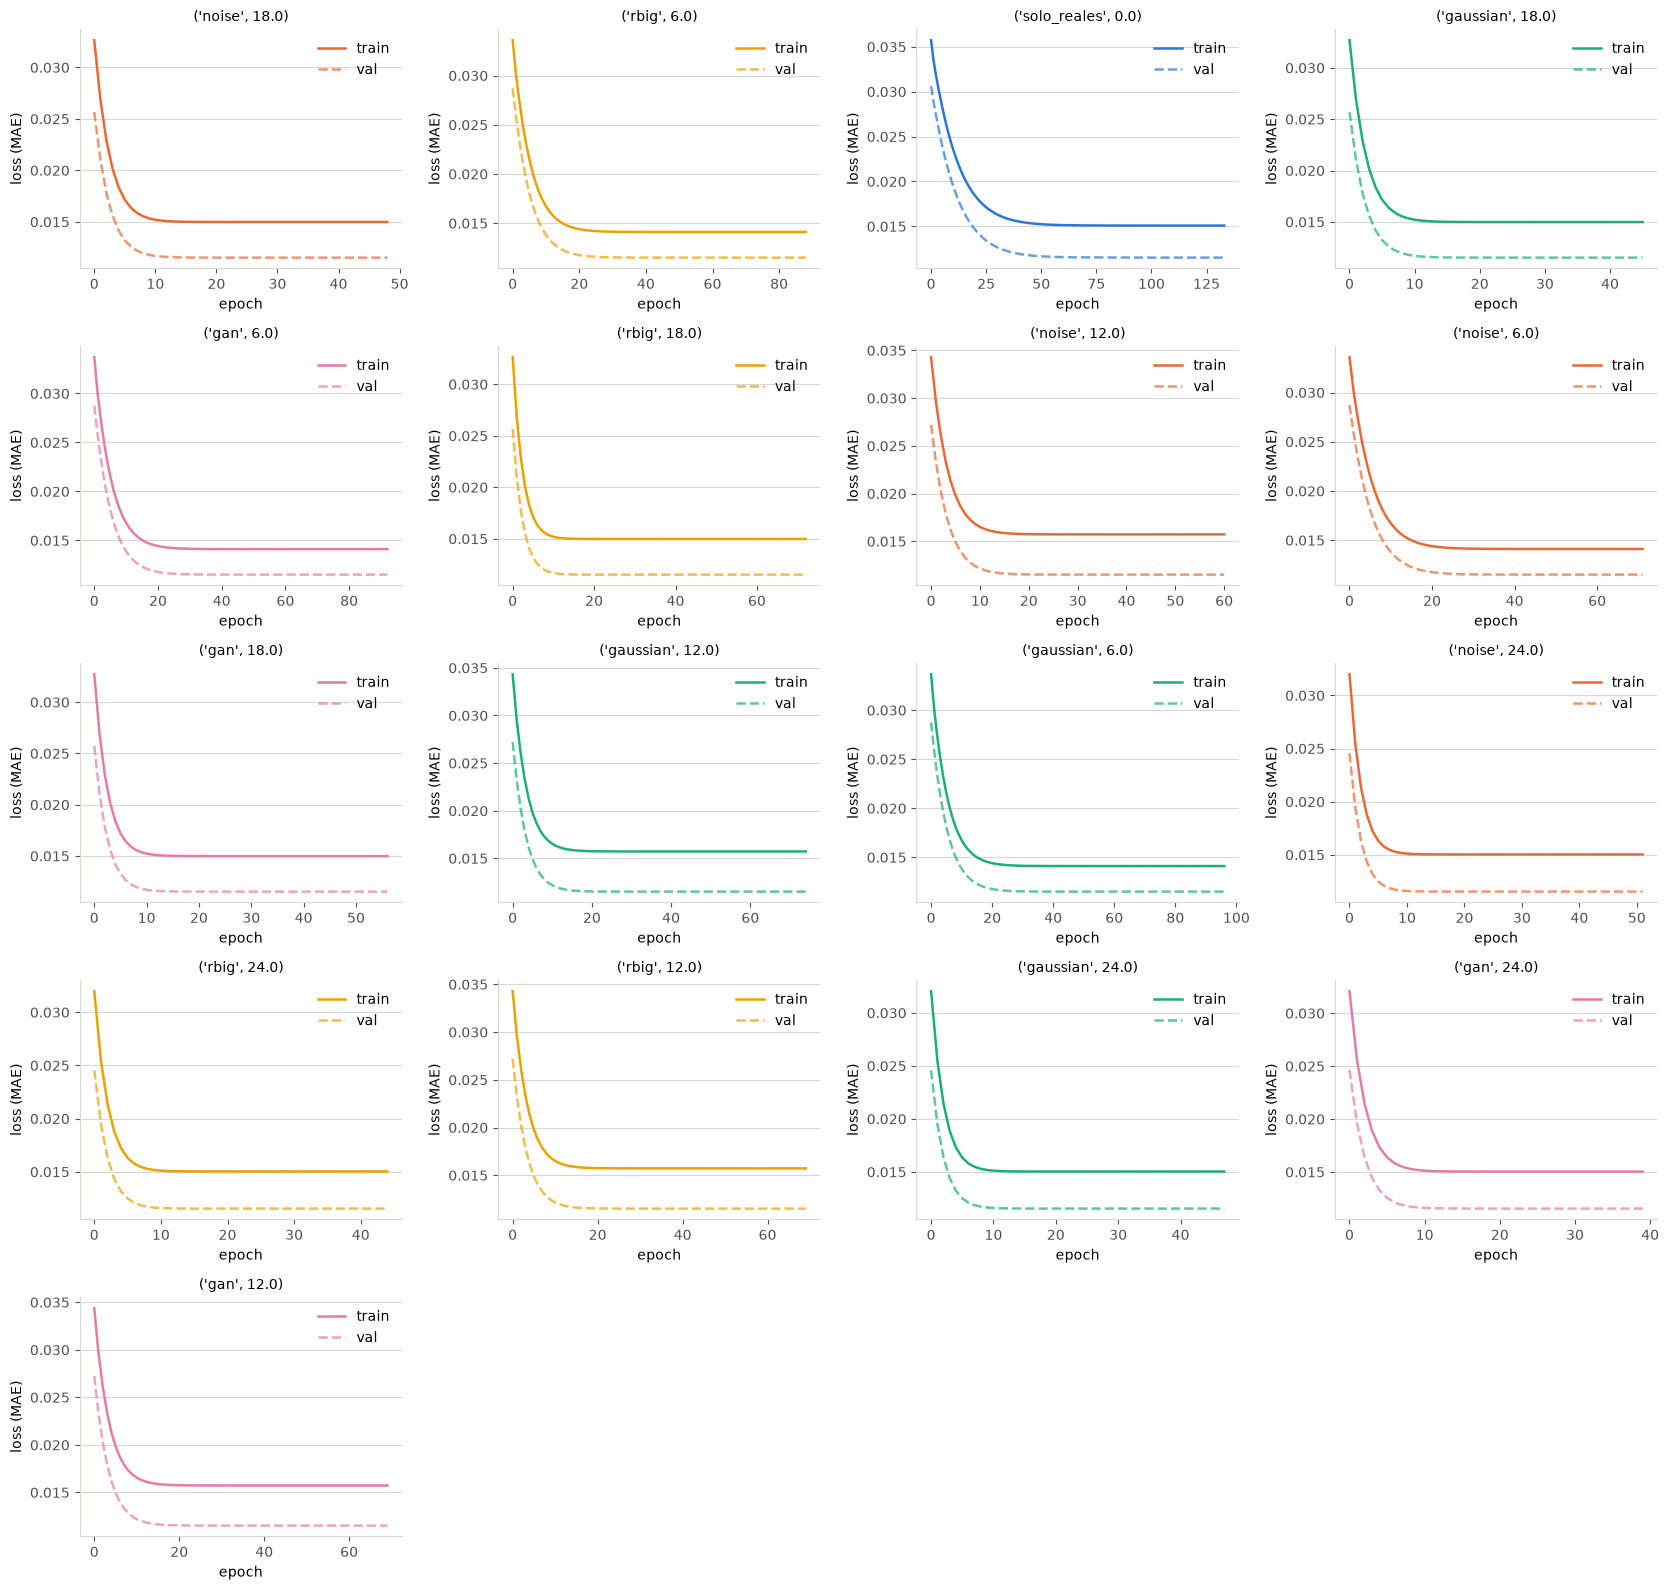

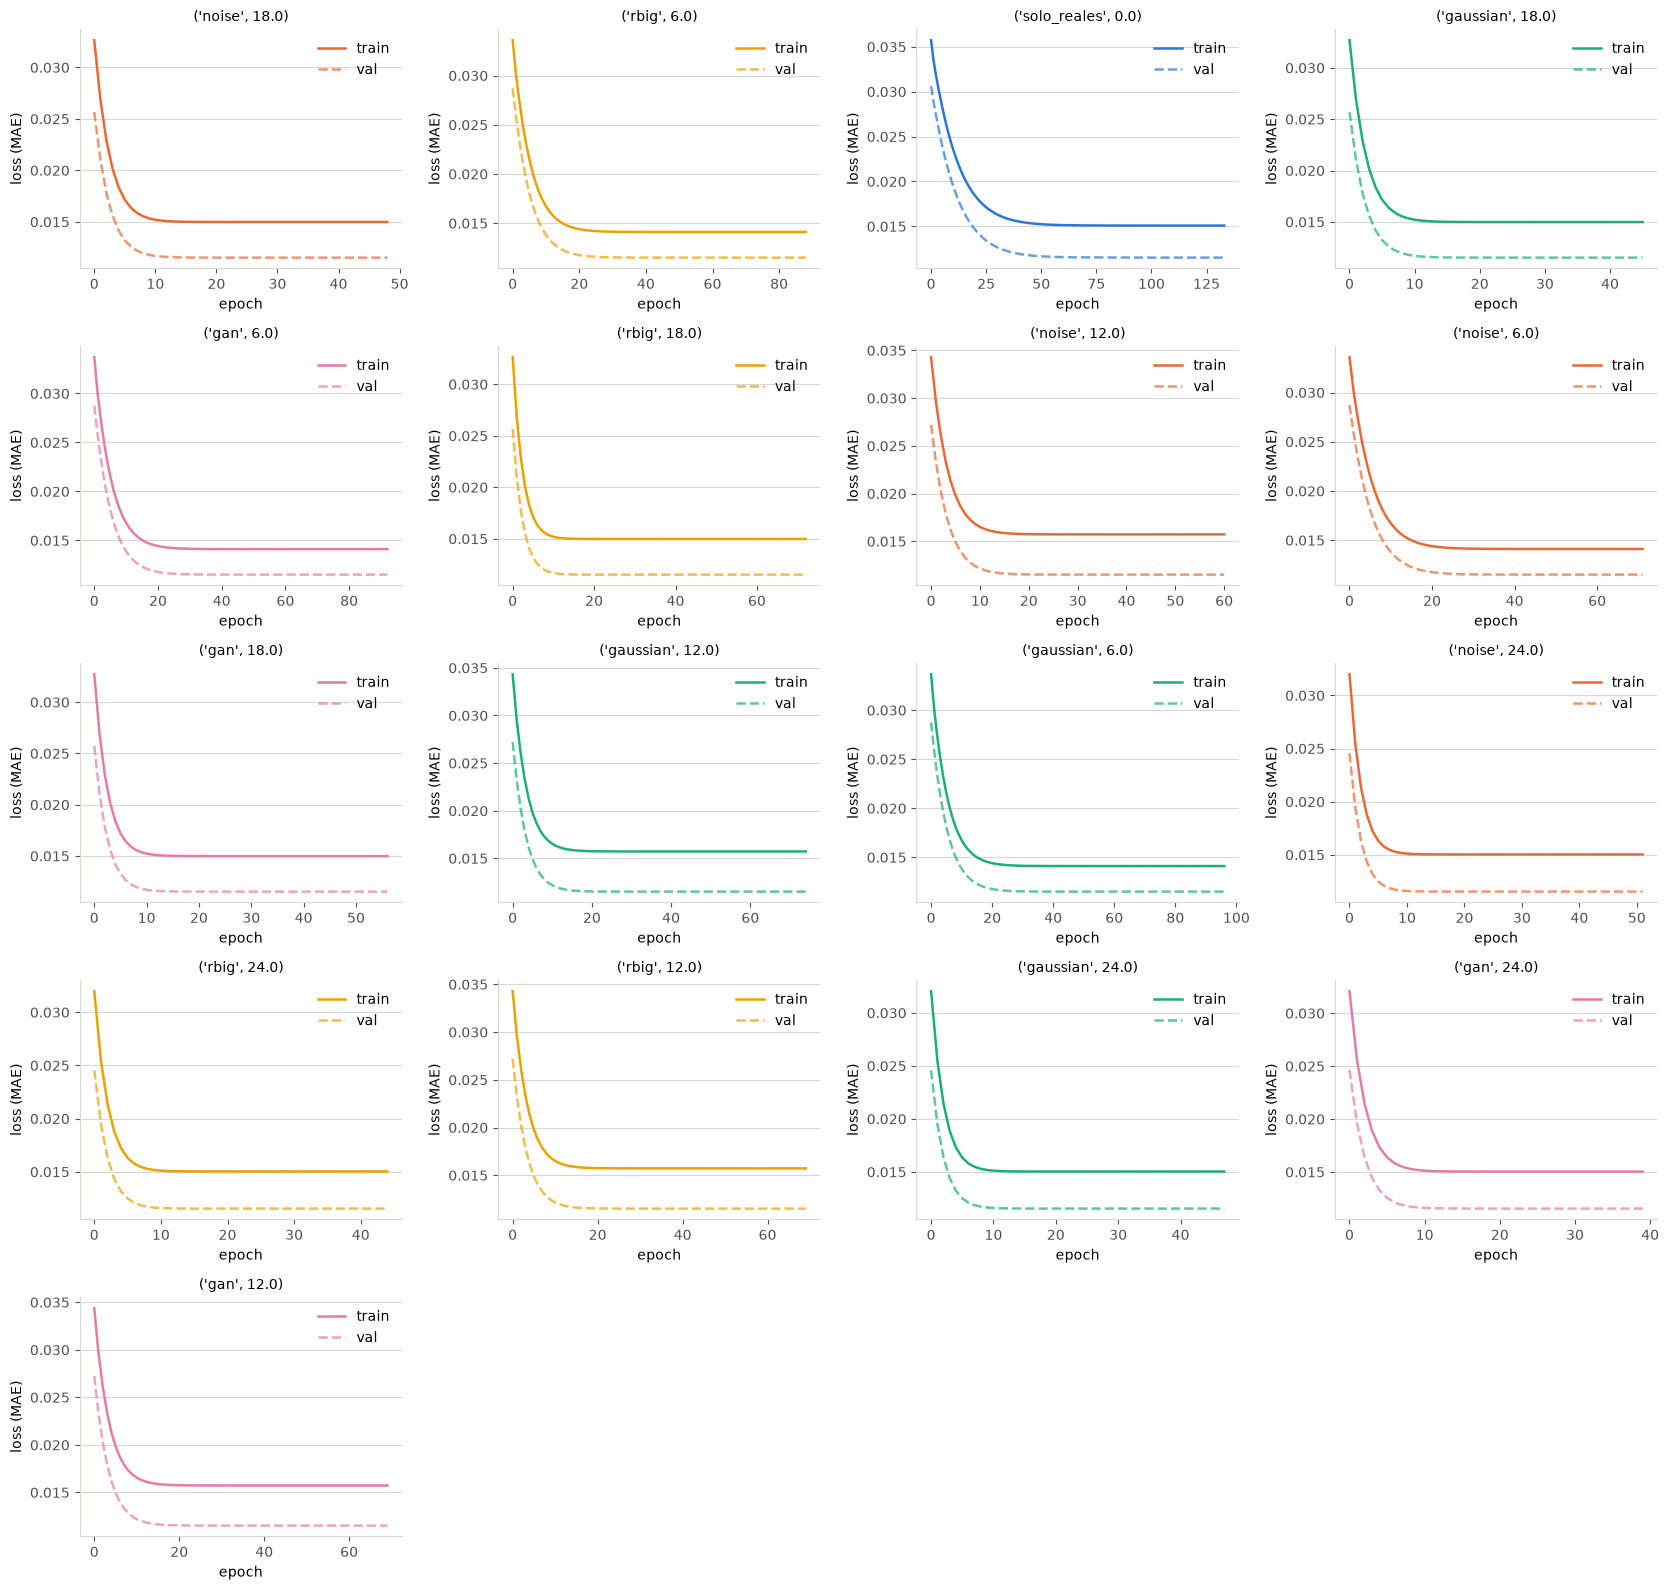

In [14]:
fig = pl.plot_loss_grid(histories, ncols=4)
pl.savefig(fig, "04_loss_curvas_rejilla")
fig

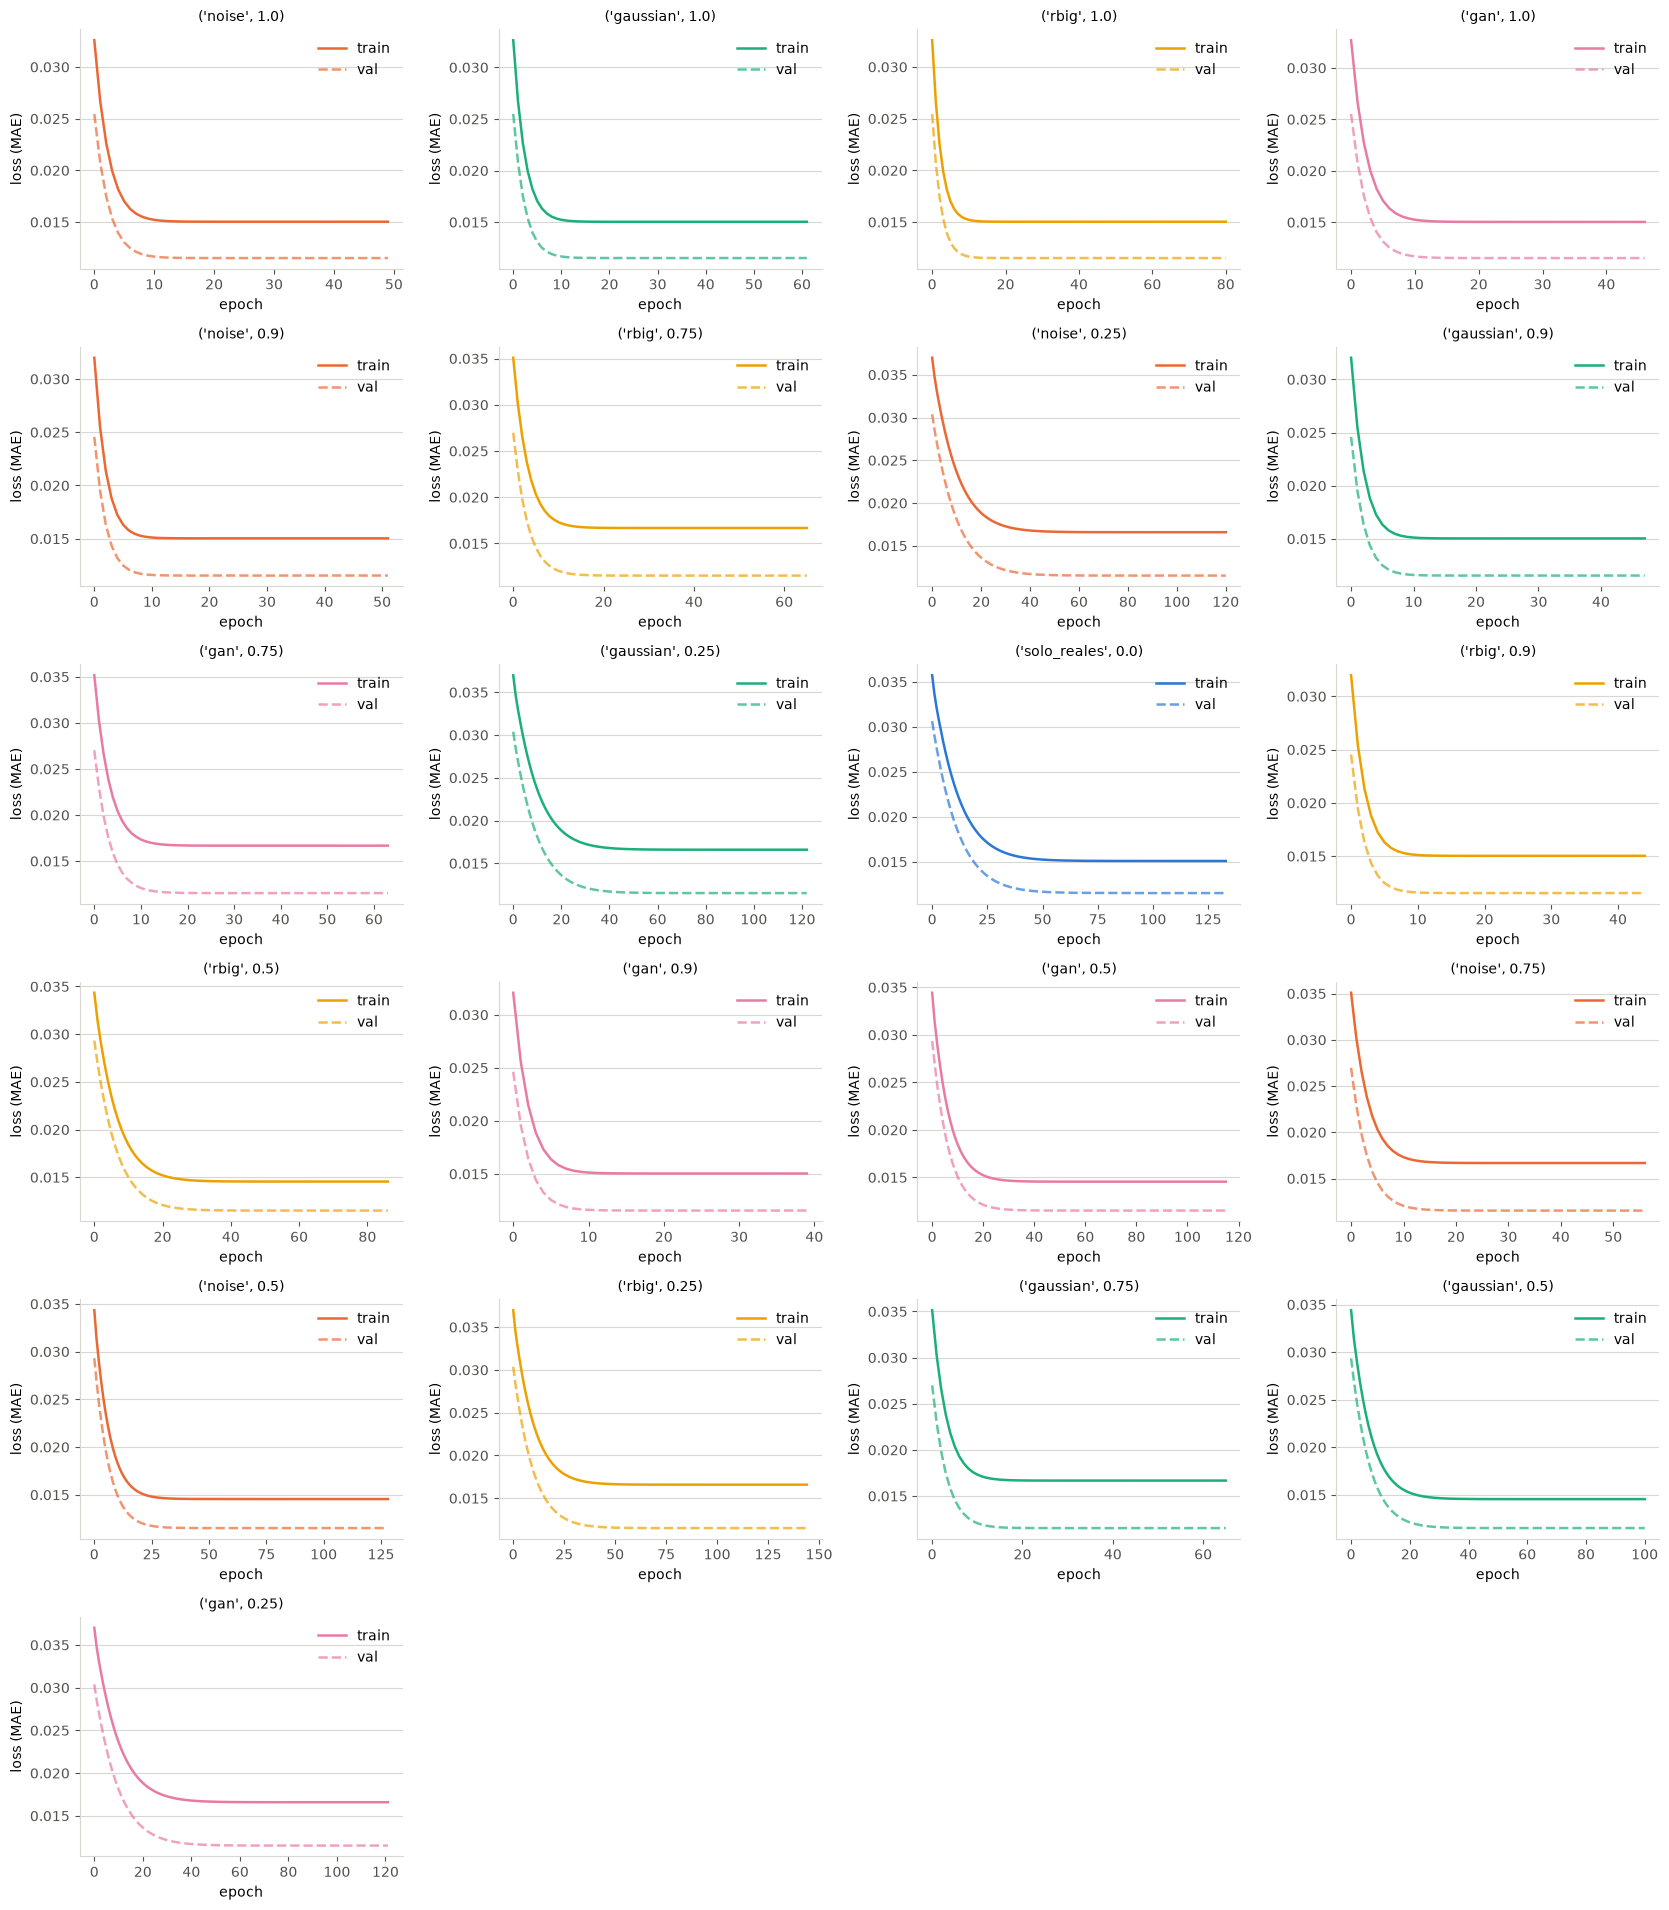

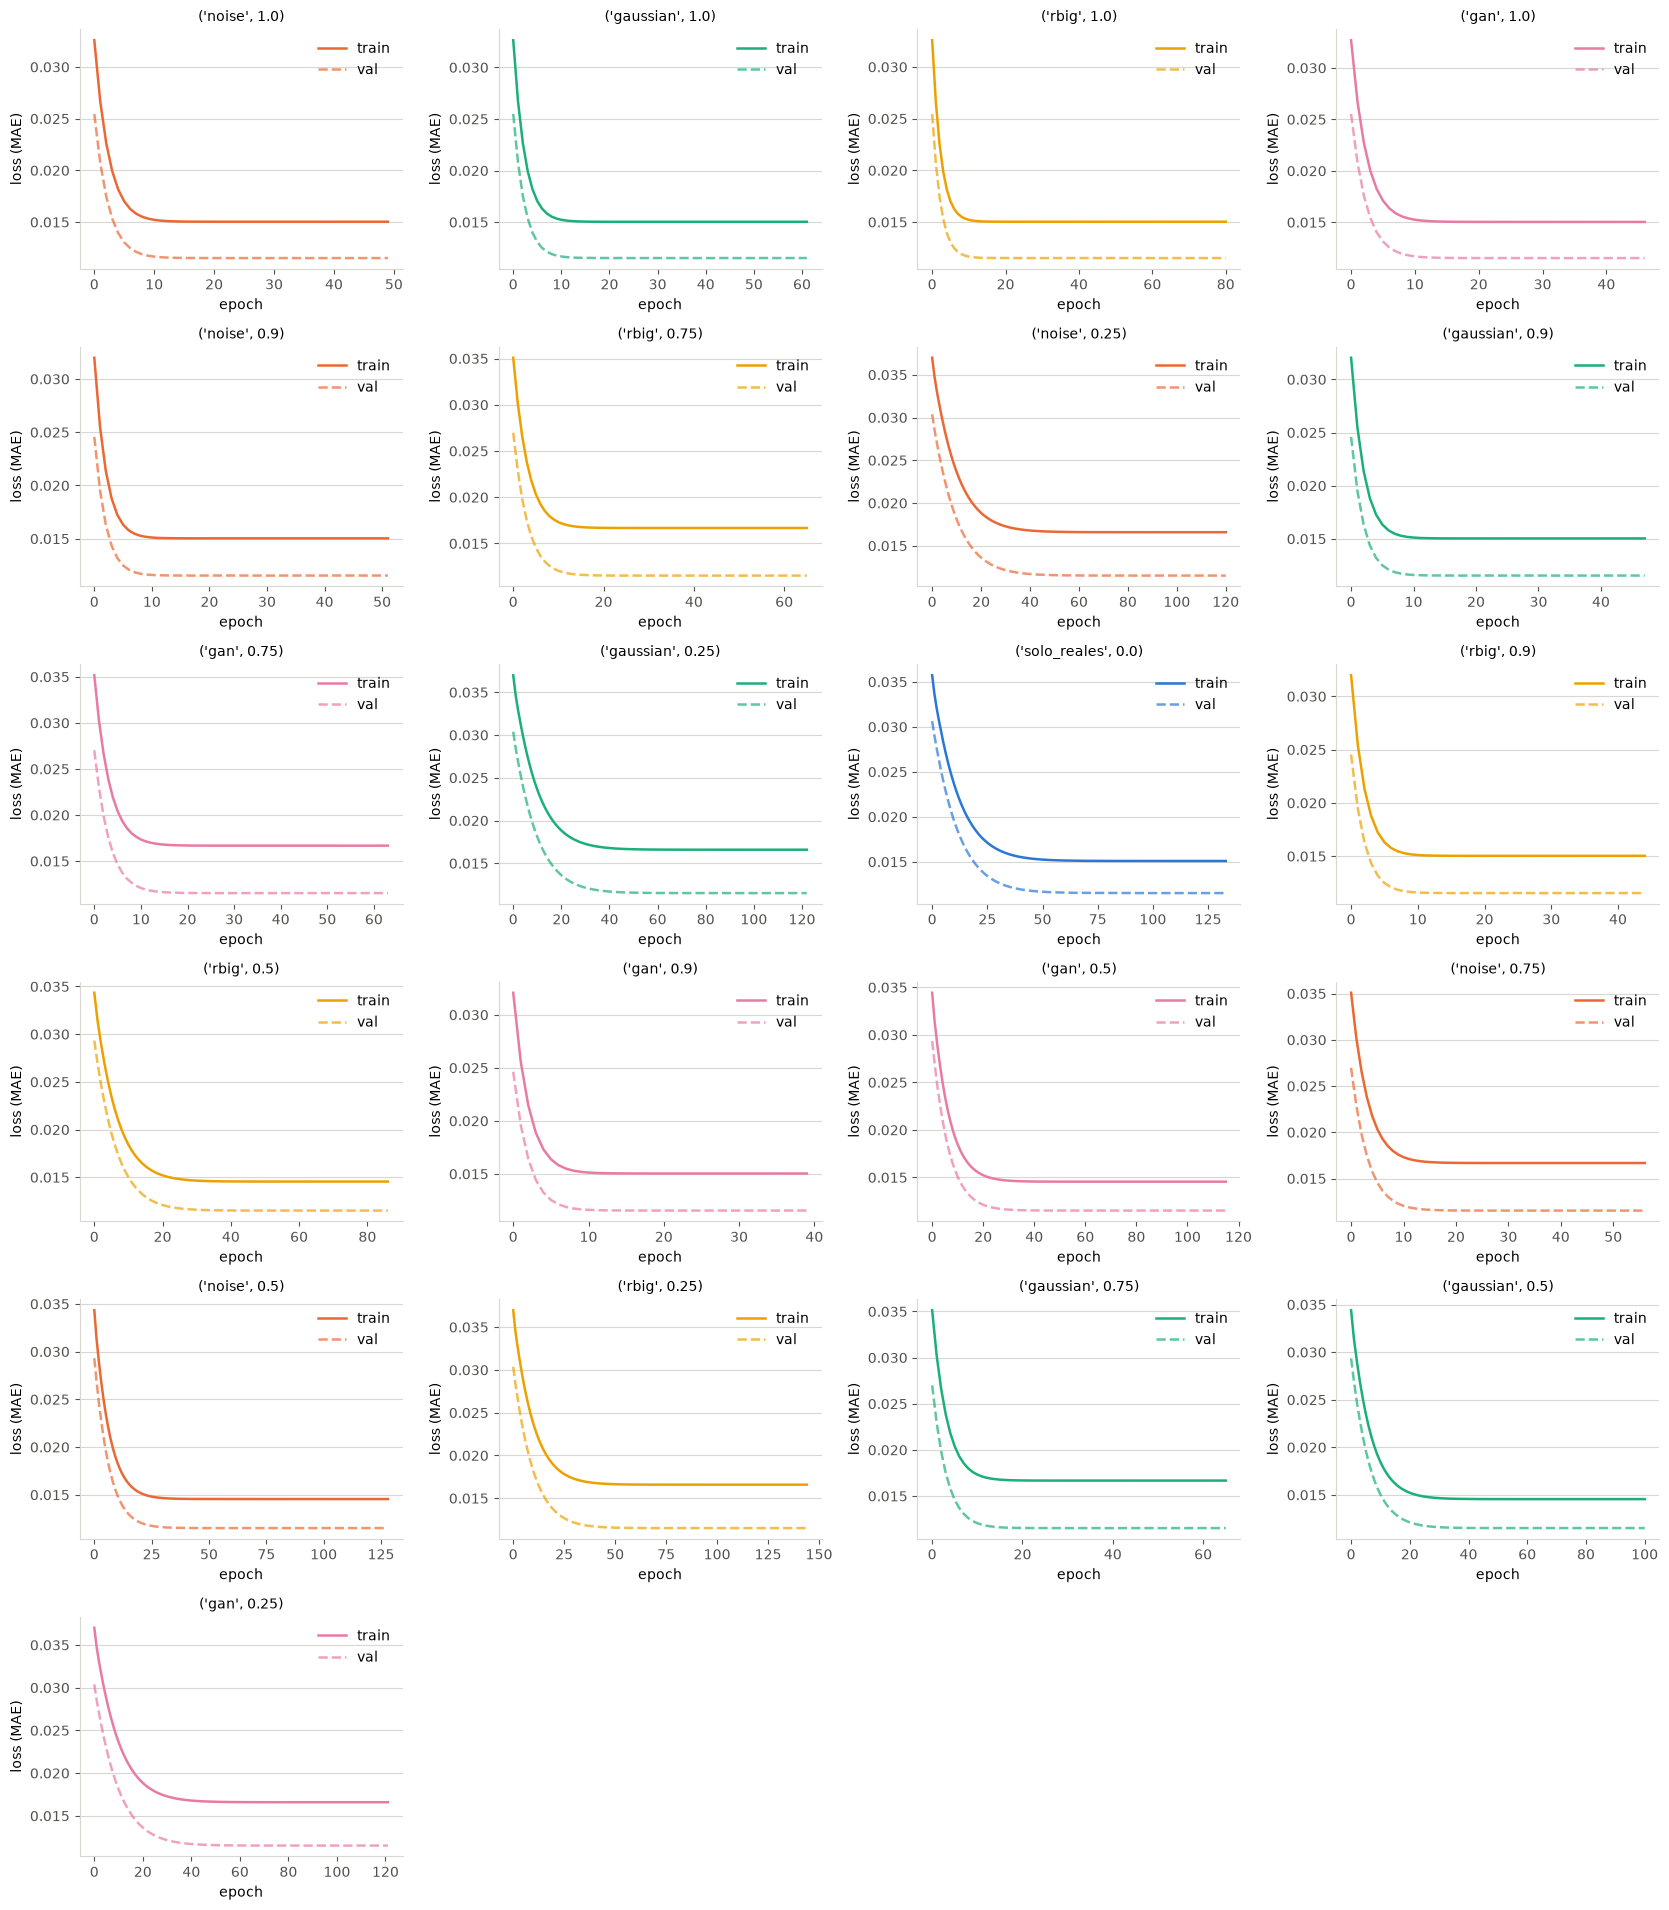

In [15]:
fig = pl.plot_loss_grid(histories_pct, ncols=4)
pl.savefig(fig, "04_loss_curvas_porcentaje")
fig

## 8. Guardar resultados consolidados (`datos/interim/`, gitignored)

El notebook 05 solo lee estos CSV/tablas — no vuelve a entrenar nada.

In [16]:
results.to_pickle(config.INTERIM_DIR / "resultados_finales.pkl")
results_pct.to_pickle(config.INTERIM_DIR / "resultados_porcentaje.pkl")
per_ticker_table.to_pickle(config.INTERIM_DIR / "resultados_por_banco.pkl")
print("Listo. Tablas en reports/tables/04_resultados_rejilla_profundidad.csv"
      " y 04_resultados_rejilla_porcentaje.csv")

Listo. Tablas en reports/tables/04_resultados_rejilla_profundidad.csv y 04_resultados_rejilla_porcentaje.csv
